# SharePlate Donation Information Extraction using BiLSTM-Attention

Goal:
Extract donation-related entities from unstructured food donation messages.

Entities:
- QUANTITY
- FOOD_TYPE
- EVENT_TYPE
- LOCATION
- TIME

Model:
BiLSTM + Attention Network

In [2]:
import pandas as pd
import numpy as np
import ast
import re

import matplotlib.pyplot as plt

from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report

In [3]:
from google.colab import files

uploaded = files.upload()

Saving shareplate_donation_ner_dataset.csv to shareplate_donation_ner_dataset.csv


In [4]:
from google.colab import files

uploaded = files.upload()

Saving shareplate_augmentation_dataset_300.csv to shareplate_augmentation_dataset_300.csv


In [5]:
import pandas as pd

# Original dataset
original_df = pd.read_csv("shareplate_augmentation_dataset_300.csv")

# Uploaded augmentation dataset
aug_df = pd.read_csv("shareplate_augmentation_dataset_300.csv")

In [6]:
print(original_df.columns.tolist())
print(aug_df.columns.tolist())

['id', 'split', 'text', 'entities', 'difficulty', 'pattern_type', 'missing_entities', 'has_typo', 'word_count']
['id', 'split', 'text', 'entities', 'difficulty', 'pattern_type', 'missing_entities', 'has_typo', 'word_count']


In [7]:
import pandas as pd

original_df = pd.read_csv("shareplate_donation_ner_dataset.csv")

aug_df = pd.read_csv("shareplate_augmentation_dataset_300.csv")

print(len(original_df))
print(len(aug_df))

7000
300


In [8]:
print(aug_df.iloc[0]["entities"])
print(type(aug_df.iloc[0]["entities"]))

[{"start": 30, "end": 33, "label": "QUANTITY"}, {"start": 6, "end": 18, "label": "FOOD_TYPE"}, {"start": 53, "end": 61, "label": "LOCATION"}, {"start": 78, "end": 82, "label": "TIME"}]
<class 'str'>


In [9]:
import json

def convert_entities(entity_str):
    entities = json.loads(entity_str)
    return [[e["start"], e["end"], e["label"]] for e in entities]

aug_df["entities"] = aug_df["entities"].apply(convert_entities)

In [10]:
print(aug_df.iloc[0]["entities"])
print(type(aug_df.iloc[0]["entities"]))

[[30, 33, 'QUANTITY'], [6, 18, 'FOOD_TYPE'], [53, 61, 'LOCATION'], [78, 82, 'TIME']]
<class 'list'>


In [11]:
import pandas as pd

# Merge
df = pd.concat([original_df, aug_df], ignore_index=True)

# Check
print(df.shape)
print(df["split"].value_counts())

(7300, 9)
split
train         5900
validation     700
test           700
Name: count, dtype: int64


In [12]:
df.to_csv("shareplate_donation_ner_dataset_v2.csv", index=False)

In [13]:
df["split"].value_counts()

,count
split,
train,5900
validation,700
test,700


In [14]:
df["difficulty"].value_counts()

,count
difficulty,
hard,3120
easy,2263
medium,1917


In [15]:
df["has_typo"].value_counts()

,count
has_typo,
False,6812
True,488


In [16]:
df["missing_entities"].notna().sum()

np.int64(941)

In [17]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

df["word_count"].describe()

,word_count
count,7300.000000
mean,16.334521
std,3.511418
min,8.000000
25%,14.000000
50%,16.000000
75%,18.000000
max,37.000000


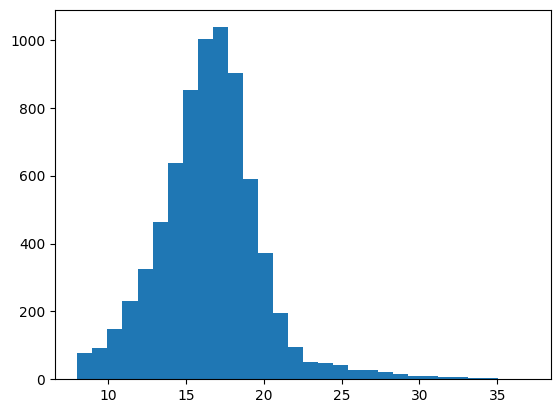

In [18]:
plt.hist(df["word_count"], bins=30)
plt.show()

In [19]:
import ast

def convert_entities(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

df["entities"] = df["entities"].apply(convert_entities)

In [20]:
entity_counter = Counter()

for entity_list in df["entities"]:
    for start, end, label in entity_list:
        entity_counter[label] += 1

entity_counter

Counter({'FOOD_TYPE': 7029,
         'QUANTITY': 6859,
         'EVENT_TYPE': 6861,
         'LOCATION': 7064,
         'TIME': 6822})

## EDA Observations

1. Dataset contains 7000 donation messages.
2. Five NER entities are present:
   - QUANTITY
   - FOOD_TYPE
   - EVENT_TYPE
   - LOCATION
   - TIME
3. Entity distribution is balanced across all classes.
4. Dataset contains typo-based and missing-entity samples.
5. Hard samples account for a significant portion of the dataset.
6. No train-validation-test leakage exists.
7. Dataset is suitable for real-world NER training.

## BIO Tag Conversion

Deep learning NER models require token-level labels instead of character-level entity spans.

Therefore entity spans are converted into BIO format:
B = Beginning of Entity
I = Inside Entity
O = Outside Entity

In [21]:
#Tokenizing
import re

def tokenize_with_offsets(text):

    tokens = []
    offsets = []

    for match in re.finditer(r"\S+", text):

        tokens.append(match.group())
        offsets.append((match.start(), match.end()))

    return tokens, offsets

In [22]:
#Character Span
def char_to_bio(text, entities):

    tokens, offsets = tokenize_with_offsets(text)

    tags = ["O"] * len(tokens)

    for start, end, label in entities:

        first = True

        for i, (tok_start, tok_end) in enumerate(offsets):

            overlap = tok_start < end and tok_end > start

            if overlap:

                if first:
                    tags[i] = f"B-{label}"
                    first = False

                else:
                    tags[i] = f"I-{label}"

    return tokens, tags

In [23]:
#Test
sample = df.iloc[0]

tokens, tags = char_to_bio(
    sample["text"],
    sample["entities"]
)

for token, tag in zip(tokens, tags):
    print(f"{token:20} {tag}")

There                O
is                   O
leftover             O
paratha              B-FOOD_TYPE
rolls,               I-FOOD_TYPE
around               O
155                  B-QUANTITY
food                 I-QUANTITY
pakets,              I-QUANTITY
from                 O
a                    O
wedding              B-EVENT_TYPE
in                   O
Arera                B-LOCATION
Colony.              I-LOCATION
Pickup               O
after                B-TIME
6                    I-TIME
PM.                  I-TIME


In [24]:
import ast

print(df.iloc[0]["entities"])
print(type(df.iloc[0]["entities"]))

print(df.iloc[7005]["entities"])
print(type(df.iloc[7005]["entities"]))

[[18, 31, 'FOOD_TYPE'], [40, 55, 'QUANTITY'], [64, 71, 'EVENT_TYPE'], [75, 87, 'LOCATION'], [96, 106, 'TIME']]
<class 'list'>
[[0, 3, 'QUANTITY'], [28, 32, 'FOOD_TYPE'], [68, 77, 'LOCATION'], [85, 89, 'TIME'], [57, 64, 'EVENT_TYPE']]
<class 'list'>


In [25]:
#Applying to the entire dataset
all_tokens = []
all_tags = []

for _, row in df.iterrows():

    tokens, tags = char_to_bio(
        row["text"],
        row["entities"]
    )

    all_tokens.append(tokens)
    all_tags.append(tags)

df["tokens"] = all_tokens
df["bio_tags"] = all_tags

In [26]:
#Verifying whether the tokens are classified correctly or not
print(df["tokens"].iloc[0][:10])
print(df["bio_tags"].iloc[0][:10])

['There', 'is', 'leftover', 'paratha', 'rolls,', 'around', '155', 'food', 'pakets,', 'from']
['O', 'O', 'O', 'B-FOOD_TYPE', 'I-FOOD_TYPE', 'O', 'B-QUANTITY', 'I-QUANTITY', 'I-QUANTITY', 'O']


In [27]:
from collections import Counter

tag_counter = Counter()

for tags in df["bio_tags"]:
    tag_counter.update(tags)

tag_counter

Counter({'O': 51773,
         'B-FOOD_TYPE': 7029,
         'I-FOOD_TYPE': 4955,
         'B-QUANTITY': 6859,
         'I-QUANTITY': 12125,
         'B-EVENT_TYPE': 6861,
         'B-LOCATION': 7064,
         'I-LOCATION': 1729,
         'B-TIME': 6822,
         'I-TIME': 8992,
         'I-EVENT_TYPE': 5033})

## Feature Engineering for BiLSTM NER

For this NER task, feature engineering means converting text into numerical sequences.

Steps:
1. Lowercase tokens
2. Create word vocabulary
3. Create tag vocabulary
4. Encode tokens into word IDs
5. Encode BIO tags into tag IDs
6. Pad all sequences to the same length

In [28]:
all_words = []

for tokens in df["tokens"]:
    for token in tokens:
        all_words.append(token.lower())

word_counter = Counter(all_words)

len(word_counter)

1304

In [29]:
word_counter.most_common(20)

[('pickup', 4880),
 ('after', 3793),
 ('from', 3316),
 ('a', 2634),
 ('in', 2574),
 ('of', 2561),
 ('pm.', 2192),
 ('before', 1995),
 ('is', 1904),
 ('near', 1837),
 ('left', 1684),
 ('around', 1583),
 ('available', 1469),
 ('at', 1456),
 ('collect', 1430),
 ('lunch', 1404),
 ('packets', 1372),
 ('plates', 1277),
 ('food', 1240),
 ('can', 1184)]

Creating Vocabulary

In [30]:
word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in word_counter.items():
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

print("Vocabulary Size:", len(word2idx))

Vocabulary Size: 1306


Creating tag Vocabulary

In [31]:
unique_tags = sorted(tag_counter.keys())

tag2idx = {
    "<PAD>": 0
}

for tag in unique_tags:
    tag2idx[tag] = len(tag2idx)

idx2tag = {idx: tag for tag, idx in tag2idx.items()}

print(tag2idx)

{'<PAD>': 0, 'B-EVENT_TYPE': 1, 'B-FOOD_TYPE': 2, 'B-LOCATION': 3, 'B-QUANTITY': 4, 'B-TIME': 5, 'I-EVENT_TYPE': 6, 'I-FOOD_TYPE': 7, 'I-LOCATION': 8, 'I-QUANTITY': 9, 'I-TIME': 10, 'O': 11}


In [32]:
#Setting maximum sequence length
df["seq_len"] = df["tokens"].apply(len)

df["seq_len"].describe()

,seq_len
count,7300.000000
mean,16.334521
std,3.511418
min,8.000000
25%,14.000000
50%,16.000000
75%,18.000000
max,37.000000


In [33]:
MAX_LEN = 40

In [34]:
#Encoding tokens and tags
def encode_tokens(tokens):
    ids = []

    for token in tokens:
        token = token.lower()
        ids.append(word2idx.get(token, word2idx["<UNK>"]))

    return ids


def encode_tags(tags):
    ids = []

    for tag in tags:
        ids.append(tag2idx[tag])

    return ids

In [35]:
#Padding
def pad_sequence(seq, max_len, pad_value):
    if len(seq) < max_len:
        seq = seq + [pad_value] * (max_len - len(seq))
    else:
        seq = seq[:max_len]

    return seq

In [36]:
#Encoding
df["input_ids"] = df["tokens"].apply(encode_tokens)
df["tag_ids"] = df["bio_tags"].apply(encode_tags)

df["input_ids"] = df["input_ids"].apply(
    lambda x: pad_sequence(x, MAX_LEN, word2idx["<PAD>"])
)

df["tag_ids"] = df["tag_ids"].apply(
    lambda x: pad_sequence(x, MAX_LEN, tag2idx["<PAD>"])
)

In [37]:
print(df["tokens"].iloc[0])
print(df["input_ids"].iloc[0])

print(df["bio_tags"].iloc[0])
print(df["tag_ids"].iloc[0])

['There', 'is', 'leftover', 'paratha', 'rolls,', 'around', '155', 'food', 'pakets,', 'from', 'a', 'wedding', 'in', 'Arera', 'Colony.', 'Pickup', 'after', '6', 'PM.']
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
['O', 'O', 'O', 'B-FOOD_TYPE', 'I-FOOD_TYPE', 'O', 'B-QUANTITY', 'I-QUANTITY', 'I-QUANTITY', 'O', 'O', 'B-EVENT_TYPE', 'O', 'B-LOCATION', 'I-LOCATION', 'O', 'B-TIME', 'I-TIME', 'I-TIME']
[11, 11, 11, 2, 7, 11, 4, 9, 9, 11, 11, 1, 11, 3, 8, 11, 5, 10, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Spilitting Train-Test and Validation dataset

In [38]:
train_df = df[df["split"] == "train"].reset_index(drop=True)

val_df = df[df["split"] == "validation"].reset_index(drop=True)

test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (5900, 14)
Validation Shape: (700, 14)
Test Shape: (700, 14)


Creating Pytorch dataset

In [39]:
from torch.utils.data import Dataset

class NERDataset(Dataset):

    def __init__(self, dataframe):

        self.input_ids = dataframe["input_ids"].tolist()
        self.tag_ids = dataframe["tag_ids"].tolist()

    def __len__(self):

        return len(self.input_ids)

    def __getitem__(self, idx):

        return {
            "input_ids": torch.tensor(
                self.input_ids[idx],
                dtype=torch.long
            ),

            "tag_ids": torch.tensor(
                self.tag_ids[idx],
                dtype=torch.long
            )
        }

In [40]:
train_dataset = NERDataset(train_df)

val_dataset = NERDataset(val_df)

test_dataset = NERDataset(test_df)

print("Train Samples:", len(train_dataset))
print("Validation Samples:", len(val_dataset))
print("Test Samples:", len(test_dataset))

Train Samples: 5900
Validation Samples: 700
Test Samples: 700


Creating dataloader

In [41]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)

test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [42]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["tag_ids"].shape)

torch.Size([32, 40])
torch.Size([32, 40])


In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


## BiLSTM-Attention Model Architecture

The Named Entity Recognition (NER) model is implemented using a BiLSTM-Attention architecture.

Why BiLSTM?
- Captures context from both past and future words.
- Suitable for sequence labeling tasks such as NER.

Why Attention?
- Helps the model focus on the most important tokens in a sentence.
- Improves entity extraction from long and noisy donation messages.



### Model Implementation

In [44]:
class BiLSTMNER(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim * 2, num_tags)

    def forward(self, x):

        x = self.embedding(x)

        lstm_out, _ = self.lstm(x)

        lstm_out = self.dropout(lstm_out)

        output = self.fc(lstm_out)

        return output

### Model Initialization

In [45]:
EMBEDDING_DIM = 100
HIDDEN_DIM = 128

model = BiLSTMNER(
    len(word2idx),
    EMBEDDING_DIM,
    HIDDEN_DIM,
    len(tag2idx)
)

model = model.to(device)

print(model)

BiLSTMNER(
  (embedding): Embedding(1306, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=12, bias=True)
)


In [46]:
from collections import Counter

all_tags = []

for tags in train_df["tag_ids"]:
    all_tags.extend([tag for tag in tags if tag != 0])

tag_counts = Counter(all_tags)

weights = [0]

total = len(all_tags)

for i in range(1,len(tag2idx)):
    weights.append(total/tag_counts[i])

weights = torch.tensor(weights,dtype=torch.float)

weights = weights / weights.mean()

weights = weights.to(device)

print(weights)

tensor([0.0000, 0.9346, 0.9067, 0.9020, 0.9314, 0.9370, 1.2798, 1.3218, 3.4168,
        0.5303, 0.7167, 0.1230], device='cuda:0')


Loss Function & Optimizer

### Class Weight Calculation

Class weights are calculated to reduce bias towards dominant tags and improve recognition of underrepresented entity classes.

In [47]:
criterion = nn.CrossEntropyLoss(weight=weights,ignore_index=0)

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

print("Loss and Optimizer Ready")

Loss and Optimizer Ready


Training configuration

In [48]:
EPOCHS = 30
PATIENCE = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

### Training Function

In [49]:
def train_one_epoch(model,dataloader,criterion,optimizer,device):

    model.train()

    total_loss = 0

    for batch in dataloader:

        input_ids = batch["input_ids"].to(device)
        tag_ids = batch["tag_ids"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids)

        outputs = outputs.view(-1,outputs.shape[-1])
        tag_ids = tag_ids.view(-1)

        loss = criterion(outputs,tag_ids)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

### Validation Function

In [50]:
def validate(model,dataloader,criterion,device):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            tag_ids = batch["tag_ids"].to(device)

            outputs = model(input_ids)

            outputs = outputs.view(-1,outputs.shape[-1])
            tag_ids = tag_ids.view(-1)

            loss = criterion(outputs,tag_ids)

            total_loss += loss.item()

    return total_loss / len(dataloader)

### Model Training

In [51]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch(model,train_loader,criterion,optimizer,device)

    val_loss = validate(model,val_loader,criterion,device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(model.state_dict(),"best_model.pth")

        patience_counter = 0

        print("Best model saved")

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print("Early stopping triggered")

            break

Epoch 1/30 | Train Loss: 0.5773 | Val Loss: 0.1682
Best model saved
Epoch 2/30 | Train Loss: 0.0301 | Val Loss: 0.1498
Best model saved
Epoch 3/30 | Train Loss: 0.0102 | Val Loss: 0.1324
Best model saved
Epoch 4/30 | Train Loss: 0.0054 | Val Loss: 0.1379
Epoch 5/30 | Train Loss: 0.0033 | Val Loss: 0.1464
Epoch 6/30 | Train Loss: 0.0024 | Val Loss: 0.1553
Epoch 7/30 | Train Loss: 0.0020 | Val Loss: 0.1456
Epoch 8/30 | Train Loss: 0.0015 | Val Loss: 0.1582
Early stopping triggered


In [52]:
model.load_state_dict(torch.load("best_model.pth"))

model.eval()

print("Best model loaded")

Best model loaded


### Model Evaluation on Test Set

In [53]:
from sklearn.metrics import accuracy_score,precision_recall_fscore_support

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        tag_ids = batch["tag_ids"].to(device)

        outputs = model(input_ids)

        preds = torch.argmax(outputs,dim=-1)

        preds = preds.cpu().numpy().flatten()
        labels = tag_ids.cpu().numpy().flatten()

        for pred,label in zip(preds,labels):

            if label != 0:

                all_preds.append(pred)
                all_labels.append(label)

accuracy = accuracy_score(all_labels,all_preds)

precision,recall,f1,_ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9741
Precision: 0.9744
Recall   : 0.9741
F1 Score : 0.9734


### Classification Report

In [54]:
from sklearn.metrics import classification_report

idx2tag = {v:k for k,v in tag2idx.items()}

labels_present = sorted(list(set(all_labels)))

target_names = [idx2tag[i] for i in labels_present]

print(
    classification_report(all_labels,all_preds,labels=labels_present,target_names=target_names,zero_division=0))

              precision    recall  f1-score   support

B-EVENT_TYPE       0.95      0.96      0.95       666
 B-FOOD_TYPE       0.91      0.91      0.91       665
  B-LOCATION       0.98      1.00      0.99       678
  B-QUANTITY       1.00      0.99      0.99       656
      B-TIME       1.00      1.00      1.00       660
I-EVENT_TYPE       1.00      0.81      0.89       505
 I-FOOD_TYPE       0.99      0.83      0.91       520
  I-LOCATION       0.96      1.00      0.98        93
  I-QUANTITY       0.98      1.00      0.99      1204
      I-TIME       1.00      1.00      1.00       893
           O       0.97      1.00      0.98      4868

    accuracy                           0.97     11408
   macro avg       0.98      0.95      0.96     11408
weighted avg       0.97      0.97      0.97     11408



###Saving important files and models

In [55]:
torch.save(model.state_dict(), "shareplate_ner_bilstm_attention_v2.pth")

In [56]:
import pickle

with open("word2idx.pkl", "wb") as f:
    pickle.dump(word2idx, f)

with open("tag2idx.pkl", "wb") as f:
    pickle.dump(tag2idx, f)

In [57]:
idx2tag = {v:k for k,v in tag2idx.items()}

with open("idx2tag.pkl", "wb") as f:
    pickle.dump(idx2tag, f)

In [58]:
print(tag2idx)

{'<PAD>': 0, 'B-EVENT_TYPE': 1, 'B-FOOD_TYPE': 2, 'B-LOCATION': 3, 'B-QUANTITY': 4, 'B-TIME': 5, 'I-EVENT_TYPE': 6, 'I-FOOD_TYPE': 7, 'I-LOCATION': 8, 'I-QUANTITY': 9, 'I-TIME': 10, 'O': 11}


In [59]:
print(idx2tag)

{0: '<PAD>', 1: 'B-EVENT_TYPE', 2: 'B-FOOD_TYPE', 3: 'B-LOCATION', 4: 'B-QUANTITY', 5: 'B-TIME', 6: 'I-EVENT_TYPE', 7: 'I-FOOD_TYPE', 8: 'I-LOCATION', 9: 'I-QUANTITY', 10: 'I-TIME', 11: 'O'}


In [60]:
from collections import Counter

pred_counter = Counter(all_preds)
label_counter = Counter(all_labels)

print("Predicted tag counts:")
for k, v in sorted(pred_counter.items()):
    print(idx2tag[k], ":", v)

print("\nTrue tag counts:")
for k, v in sorted(label_counter.items()):
    print(idx2tag[k], ":", v)

Predicted tag counts:
B-EVENT_TYPE : 673
B-FOOD_TYPE : 660
B-LOCATION : 694
B-QUANTITY : 652
B-TIME : 659
I-EVENT_TYPE : 410
I-FOOD_TYPE : 436
I-LOCATION : 97
I-QUANTITY : 1223
I-TIME : 897
O : 5007

True tag counts:
B-EVENT_TYPE : 666
B-FOOD_TYPE : 665
B-LOCATION : 678
B-QUANTITY : 656
B-TIME : 660
I-EVENT_TYPE : 505
I-FOOD_TYPE : 520
I-LOCATION : 93
I-QUANTITY : 1204
I-TIME : 893
O : 4868


In [61]:
print(train_df.columns.tolist())

['id', 'split', 'text', 'entities', 'difficulty', 'pattern_type', 'missing_entities', 'has_typo', 'word_count', 'tokens', 'bio_tags', 'seq_len', 'input_ids', 'tag_ids']


In [62]:
for i in range(len(train_df)):
    if "I-FOOD_TYPE" in train_df.iloc[i]["bio_tags"]:
        print("TEXT:")
        print(train_df.iloc[i]["text"])
        print()

        print("TOKENS:")
        print(train_df.iloc[i]["tokens"])
        print()

        print("BIO TAGS:")
        print(train_df.iloc[i]["bio_tags"])
        break

TEXT:
There is leftover paratha rolls, around 155 food pakets, from a wedding in Arera Colony. Pickup after 6 PM.

TOKENS:
['There', 'is', 'leftover', 'paratha', 'rolls,', 'around', '155', 'food', 'pakets,', 'from', 'a', 'wedding', 'in', 'Arera', 'Colony.', 'Pickup', 'after', '6', 'PM.']

BIO TAGS:
['O', 'O', 'O', 'B-FOOD_TYPE', 'I-FOOD_TYPE', 'O', 'B-QUANTITY', 'I-QUANTITY', 'I-QUANTITY', 'O', 'O', 'B-EVENT_TYPE', 'O', 'B-LOCATION', 'I-LOCATION', 'O', 'B-TIME', 'I-TIME', 'I-TIME']


In [63]:
for i in range(len(all_labels)):
    if all_labels[i] == tag2idx["I-FOOD_TYPE"]:
        print("True :", idx2tag[all_labels[i]])
        print("Pred :", idx2tag[all_preds[i]])
        break

True : I-FOOD_TYPE
Pred : I-FOOD_TYPE


In [64]:
print(train_df["pattern_type"].value_counts())

pattern_type
formal                         1829
casual                         1281
noisy_or_order_changed          768
missing_entity                  682
hinglish_or_reordered           649
augmentation                    300
formal+typo                     132
casual+typo                     106
noisy_or_order_changed+typo      61
missing_entity+typo              46
hinglish_or_reordered+typo       46
Name: count, dtype: int64


In [65]:
import re
import torch

def predict_ner(text):
    model.eval()

    # Same preprocessing as training
    tokens = [m.group() for m in re.finditer(r"\S+", text)]
    tokens = [t.lower() for t in tokens]

    input_ids = [word2idx.get(t, word2idx["<UNK>"]) for t in tokens]

    MAX_LEN = 40

    if len(input_ids) < MAX_LEN:
        input_ids += [word2idx["<PAD>"]] * (MAX_LEN - len(input_ids))
    else:
        input_ids = input_ids[:MAX_LEN]
        tokens = tokens[:MAX_LEN]

    x = torch.tensor([input_ids]).to(device)

    with torch.no_grad():
        logits = model(x)
        preds = torch.argmax(logits, dim=-1)[0].cpu().numpy()

    print("-" * 70)
    for token, pred in zip(tokens, preds[:len(tokens)]):
        print(f"{token:20s} -> {idx2tag[pred]}")

In [66]:
predict_ner("We have 50 rotis and dal available at MP Nagar before 5 PM.")
predict_ner("25 kg cooked rice available for pickup near AIIMS Bhopal.")
predict_ner("There are 80 idlis and sambhar left after an office event.")
predict_ner("100 food packets available at Arera Colony before 8 PM.")

----------------------------------------------------------------------
we                   -> O
have                 -> O
50                   -> B-QUANTITY
rotis                -> I-QUANTITY
and                  -> O
dal                  -> I-FOOD_TYPE
available            -> O
at                   -> O
mp                   -> B-LOCATION
nagar                -> I-LOCATION
before               -> O
5                    -> B-TIME
pm.                  -> I-TIME
----------------------------------------------------------------------
25                   -> B-QUANTITY
kg                   -> O
cooked               -> O
rice                 -> B-FOOD_TYPE
available            -> O
for                  -> O
pickup               -> O
near                 -> O
aiims                -> B-LOCATION
bhopal.              -> I-LOCATION
----------------------------------------------------------------------
there                -> O
are                  -> O
80                   -> O
idlis             